# Part 3, Task 6.1 — Model Versioning (visual companion)

`mlops/model_versioning.py` pulls every model version's parameters and
metrics straight from the MLflow tracking store and writes a markdown
comparison table. This notebook calls the exact same function — no logic
is duplicated here — and adds bar-chart comparisons on top, so the model
comparison is easier to read at a glance than a table alone.

In [1]:
import sys
from pathlib import Path

for _candidate in (Path.cwd(), Path.cwd() / "scripts", Path.cwd().parent / "scripts"):
    if (_candidate / "common.py").exists():
        sys.path.insert(0, str(_candidate))
        break
for _candidate in (Path.cwd().parent / "mlops", Path.cwd() / "mlops"):
    if (_candidate / "model_versioning.py").exists():
        sys.path.insert(0, str(_candidate))
        break

import matplotlib.pyplot as plt
import pandas as pd

from model_versioning import build_comparison_table

pd.set_option("display.max_columns", None)
FIGURES_DIR = Path.cwd() / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/09/15 12:28:37 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /usr/local/lib/python3.11/dist-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


## All logged model runs

One row per MLflow run, across every Part 3 experiment.

In [2]:
table = build_comparison_table()
table

,experiment,run_name,start_time,n_estimators,lookback,model,max_depth,units,batch_size,epochs,task,MAE,R2,final_train_loss,final_val_loss,accuracy,precision,roc_auc,f1,recall
1,traffic_deep_learning,lstm_traffic_volume,2026-09-14 05:18:20.731000+00:00,NaN,24,LSTM,NaN,32,256,10,NaN,251.332382,0.969207,0.070997,0.030356,NaN,NaN,NaN,NaN,NaN
3,traffic_deep_learning,lstm_traffic_volume,2026-09-14 05:16:35.082000+00:00,NaN,24,LSTM,NaN,32,256,10,NaN,247.591278,0.968120,0.075598,0.030758,NaN,NaN,NaN,NaN,NaN
0,traffic_deep_learning,rf_lag_traffic_volume_explainability,2026-09-14 05:19:02.184000+00:00,200,24,RandomForestRegressor,10,NaN,NaN,NaN,NaN,158.435284,0.983814,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,traffic_supervised_ml,classification_LogisticRegression,2026-09-14 05:08:29.032000+00:00,NaN,NaN,LogisticRegression,NaN,NaN,NaN,NaN,classification_high_risk,NaN,NaN,NaN,NaN,0.959704,0.710456,0.994066,0.829421,0.996241
6,traffic_supervised_ml,classification_RandomForestClassifier,2026-09-14 05:08:29.361000+00:00,NaN,NaN,RandomForestClassifier,NaN,NaN,NaN,NaN,classification_high_risk,NaN,NaN,NaN,NaN,0.983611,0.862595,0.996891,0.922449,0.991228
4,traffic_supervised_ml,regression_GradientBoostingRegressor,2026-09-14 05:08:30.985000+00:00,NaN,NaN,GradientBoostingRegressor,NaN,NaN,NaN,NaN,regression_traffic_volume,278.339483,0.937639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,traffic_supervised_ml,regression_LinearRegression,2026-09-14 05:08:30.926000+00:00,NaN,NaN,LinearRegression,NaN,NaN,NaN,NaN,regression_traffic_volume,832.121659,0.706477,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Regression / sequential models: R² comparison

Includes the two plain regression models (Task 1), the lag-feature Random
Forest, and the LSTM (both Task 3) — all predicting the same target
(traffic volume), so R² is directly comparable across all of them. Where a
model was trained more than once, only its best-R² run is shown.

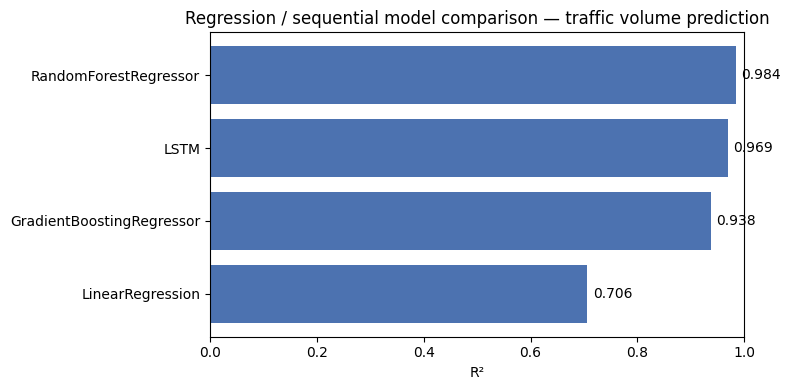

In [3]:
reg = table[table["task"] == "regression_traffic_volume"]
lag_rf = table[table["run_name"].str.contains("rf_lag", na=False)]
lstm = table[table["model"] == "LSTM"]
combined = pd.concat([reg, lag_rf, lstm])[["run_name", "model", "R2"]].dropna(subset=["R2"])
combined = combined.loc[combined.groupby("model")["R2"].idxmax()].sort_values("R2")

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(combined["model"], combined["R2"], color="#4C72B0")
ax.set_xlabel("R²")
ax.set_xlim(0, 1)
ax.set_title("Regression / sequential model comparison — traffic volume prediction")
for bar, value in zip(bars, combined["R2"]):
    ax.text(value + 0.01, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_versioning_regression_r2.png", dpi=120)
plt.show()

## Classification models: precision vs. recall

Both models predict the proxy `high_risk` label (Task 1). Precision matters
most here — a false alarm has a real operational cost — so the model with
the better precision at comparable recall is the stronger candidate.

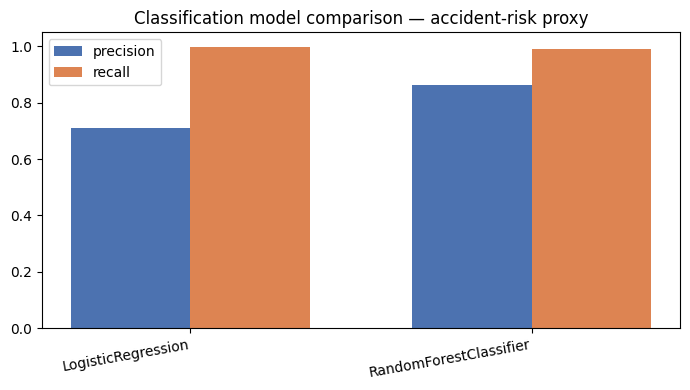

In [4]:
clf = table[table["task"] == "classification_high_risk"][
    ["run_name", "model", "precision", "recall", "f1", "roc_auc"]
].dropna(subset=["precision"])

x = range(len(clf))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([i - width / 2 for i in x], clf["precision"], width, label="precision", color="#4C72B0")
ax.bar([i + width / 2 for i in x], clf["recall"], width, label="recall", color="#DD8452")
ax.set_xticks(list(x))
ax.set_xticklabels(clf["model"], rotation=10, ha="right")
ax.set_ylim(0, 1.05)
ax.set_title("Classification model comparison — accident-risk proxy")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_versioning_classification.png", dpi=120)
plt.show()

## Recommended production candidates

See `mlops/model_versioning.md` for the full written recommendation — in
short: `RandomForestClassifier` for accident-risk (highest precision at
near-identical recall), `GradientBoostingRegressor` for traffic volume
without recent history, and the lag-feature `RandomForestRegressor` as the
best available sequential predictor — marginally ahead of the LSTM on this
dataset size, and far cheaper to retrain.